# Legacy FScanpy: executed full-sequence reference

This notebook contains completed predictions from the **older two HistGradientBoosting models**. It is kept for comparison with the [current PyTorch tutorial](predict_sample.ipynb). Both old classifiers use the central 33 bp features; the old `long.pkl` classifier is not the current PyTorch 399 bp neural model.

All code cells below were rerun with the retained legacy models. They use the same five full sequences as the original sample, weights 0.6 for rows 0–3 and 0.4 for row 4, and display thresholds 0.2 /0.2. The corrected titles follow the current legacy table IDs 0,1,5,12,14; the last two short-sequence plots in the original saved notebook have mismatched code/title states.

For the exact six historical figures, see the [original saved-output archive](predict_sample_legacy_saved.ipynb). In particular, the historical Sequence 1 figures do not fully match a rerun with the retained model/source files. This completed replay does not claim to reconstruct the unavailable historical execution environment.

Reading the saved results needs no installation. Rerunning requires the original legacy model files and compatible old FScanpy implementation. The current release deliberately fails the model check below rather than overwriting this reference with new-model predictions.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier
from FScanpy import PRFPredictor

predictor = PRFPredictor()
assert isinstance(predictor.short_model, HistGradientBoostingClassifier)
assert isinstance(predictor.long_model, HistGradientBoostingClassifier), "Rerun this reference with the original two legacy HistGB models."
data_folder = Path("data")
if not data_folder.is_dir():
    data_folder = Path("tutorial") / "data"
data = pd.read_csv(data_folder / "predict_sample_legacy_examples.csv")
display(data.drop(columns="Full_Sequence"))

,Sequence_ID,Position
0,0,114
1,1,1794
2,5,234
3,12,129
4,14,216


## How to read these plots

The two red heatmaps and the black bar chart use the original plotting implementation. The upper“FS site” heatmap marks model-selected candidates at score≥0.8; it is not ground truth. The green dashed line is added independently from the legacy data table. Positions are 0-based. The original text says 113 for Sequence 0, while the table and replay use 114; this discrepancy is retained here rather than silently equated.

As in the current API, step 1 rounds positions to codon starts when building its windows. The repeated rows should not be interpreted as independent high-resolution evidence.

In [2]:
results_by_row = {}
def legacy_plot(row_number, step=3):
    row = data.iloc[row_number]
    weight = 0.4 if row_number == 4 else 0.6
    result, figure = predictor.plot_sequence_prediction(str(row.Full_Sequence),
        window_size=step, short_threshold=0.2, long_threshold=0.2,
        ensemble_weight=weight, figsize=(14,8), dpi=120,
        title=f"Legacy Sequence {int(row.Sequence_ID)} | complete CDS | step {step}")
    grid = figure.axes[0].get_subplotspec().get_gridspec()
    grid.set_height_ratios([0.35,0.35,2.8])
    figure.axes[0].set_title("FS site (predicted candidates)", fontsize=10)
    figure.axes[1].set_title("Prediction", fontsize=10)
    for axis in figure.axes:
        axis.axvline(int(row.Position), color="#009E73", linestyle="--", linewidth=1.2)
    figure.axes[2].set_xlabel("Codon start (0-based nt)")
    figure.tight_layout(rect=(0,0,1,0.94))
    results_by_row[(row_number,step)] = result
    return result, figure

## Sequence 0: relatively prominent reference, with a secondary peak

Reference 114 is about 0.910; the peak at 174 is also strong, about 0.874. The full curve does not justify an entirely unambiguous interpretation.

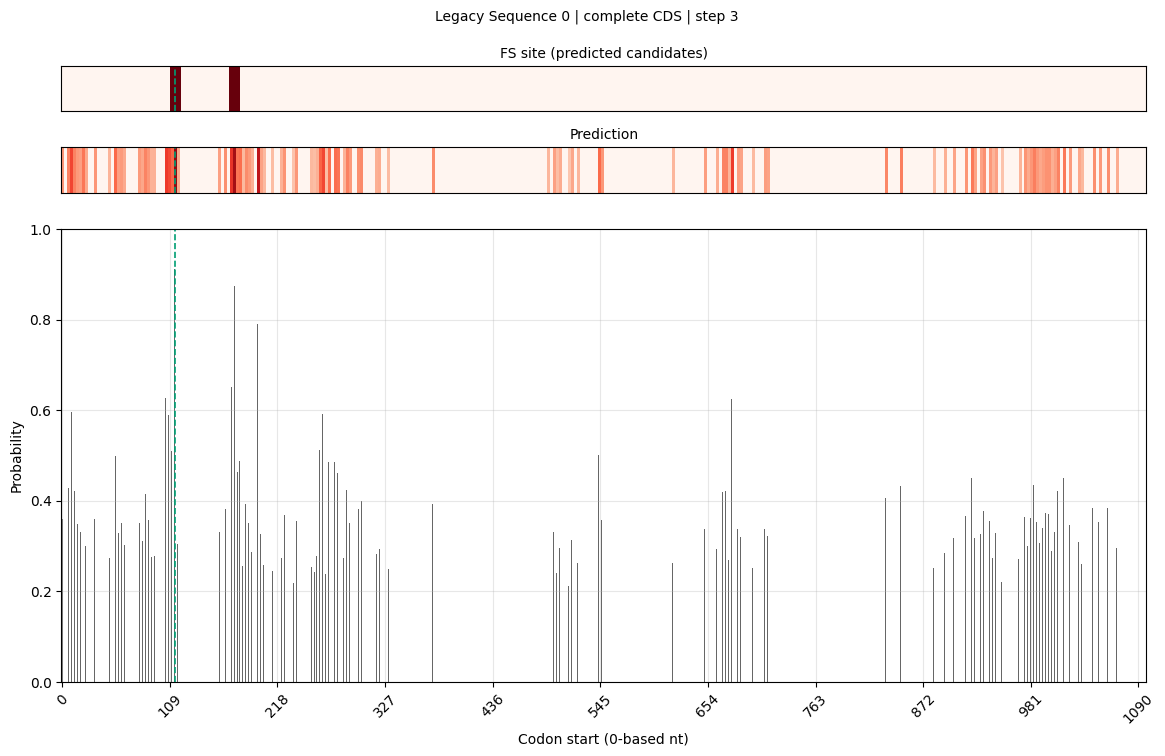

In [3]:
result, figure = legacy_plot(0, step=3)
plt.show()

## Sequence 1: many peaks across the full CDS

In this retained-model replay, the reference 1794 is about 0.942 and the remote 783 peak is about 0.920. Local support around the reference is more concentrated, but other candidates remain.

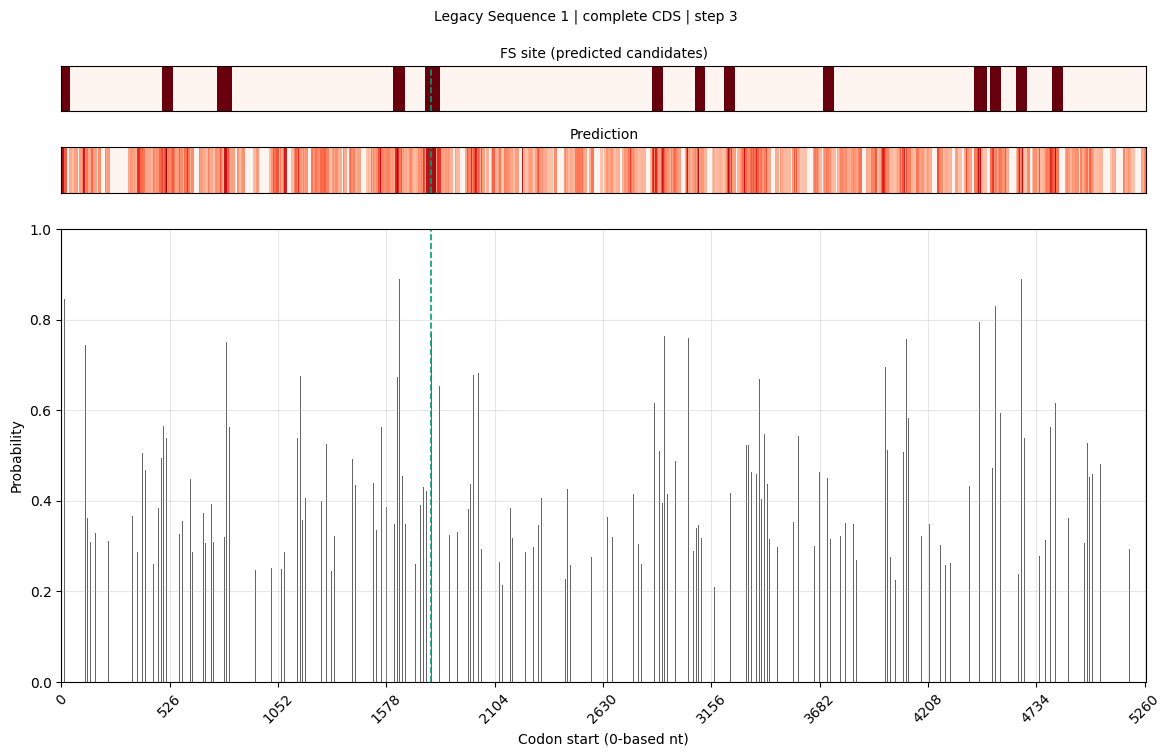

In [4]:
result, figure = legacy_plot(1, step=3)
plt.show()

## Sequence 1: step 1 repeats codon-window predictions

This view uses the same model and weight. Extra output rows make the chart denser without adding independent windows. It is not a separate confirmation of the reference.

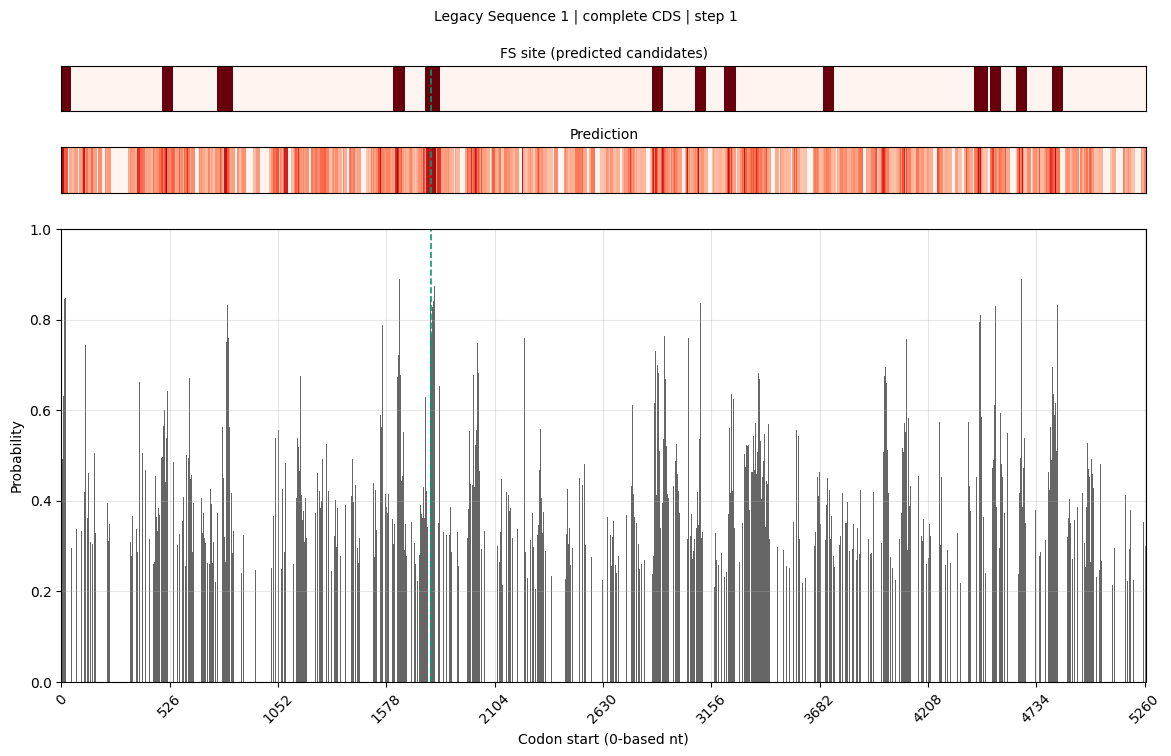

In [5]:
result, figure = legacy_plot(1, step=1)
plt.show()

## Sequence 5: a relatively sparse short CDS

The current legacy table row 2 is 429 nt long, with reference 234 and a peak about 0.777. This is the short-sequence situation illustrated by the historical saved Sequence 5 figure.

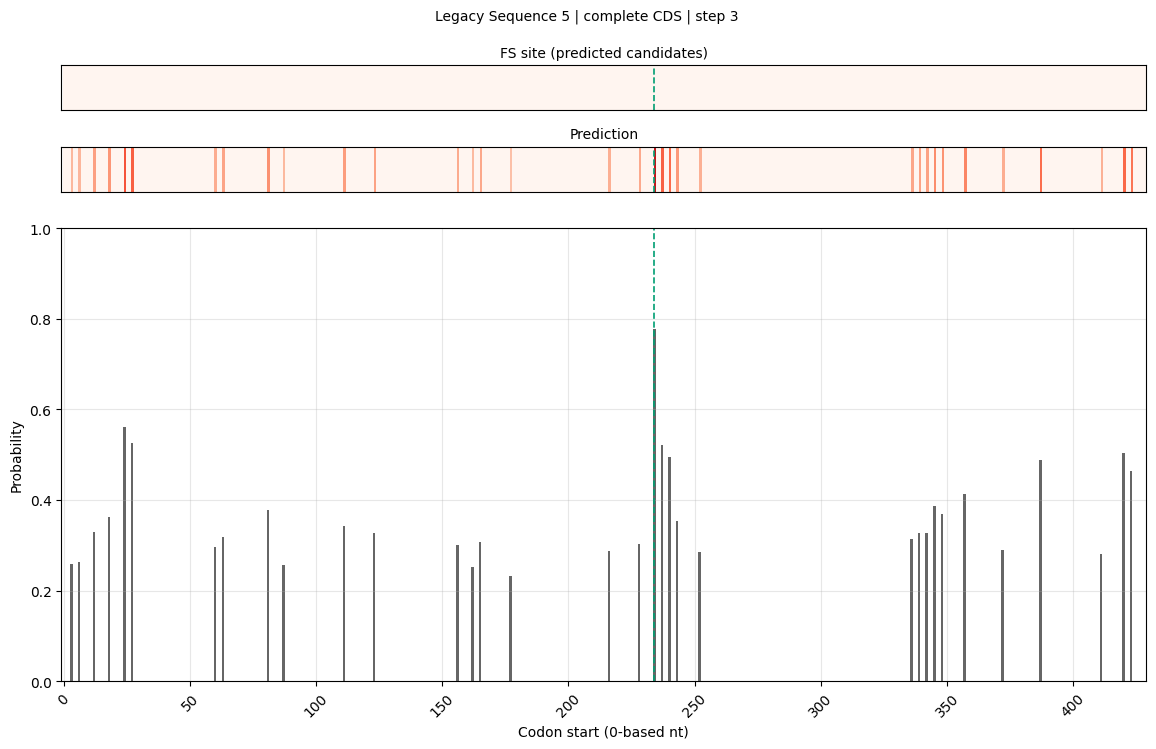

In [6]:
result, figure = legacy_plot(2, step=3)
plt.show()

## Sequence 12: another short-CDS reference

The current legacy table row 3 is 429 nt long, with reference 129 and a peak about 0.854. Its historical saved counterpart has the title Sequence 7; code and saved titles had diverged.

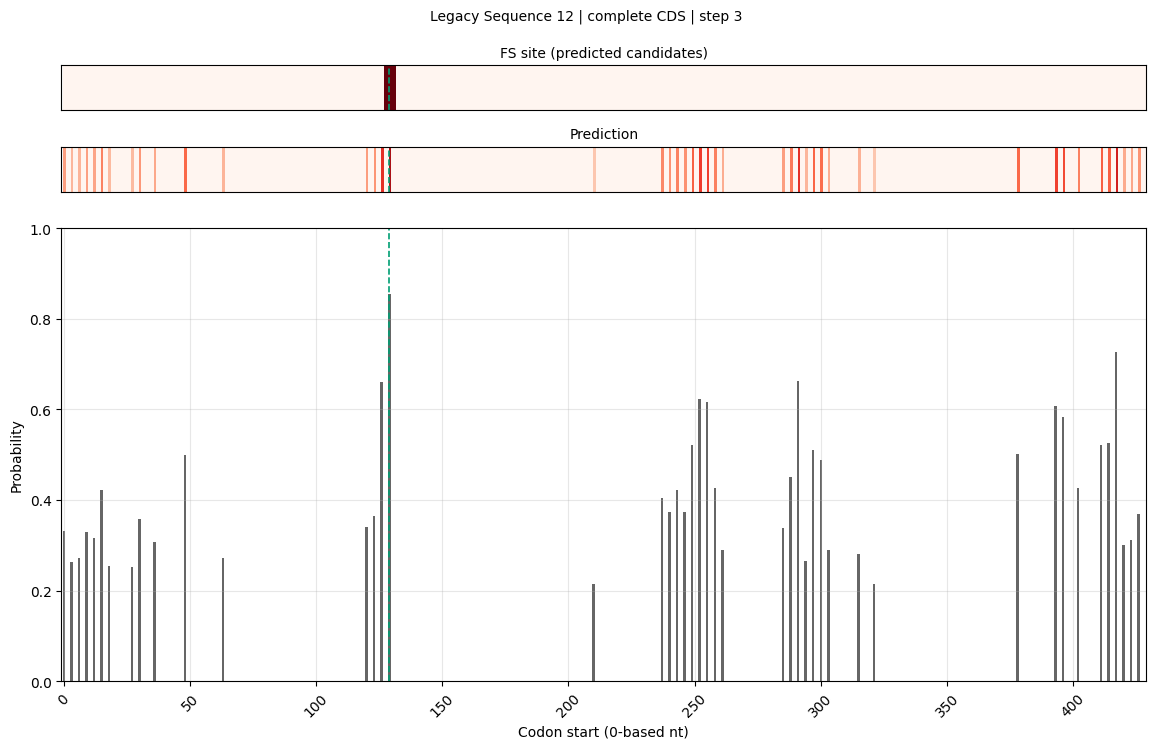

In [7]:
result, figure = legacy_plot(3, step=3)
plt.show()

## Sequence 14: strong competing candidates

Reference 216 is about 0.869; peaks near 81 and 135 are about 0.864 and 0.813. Their relative heights do not provide a unique biological conclusion.

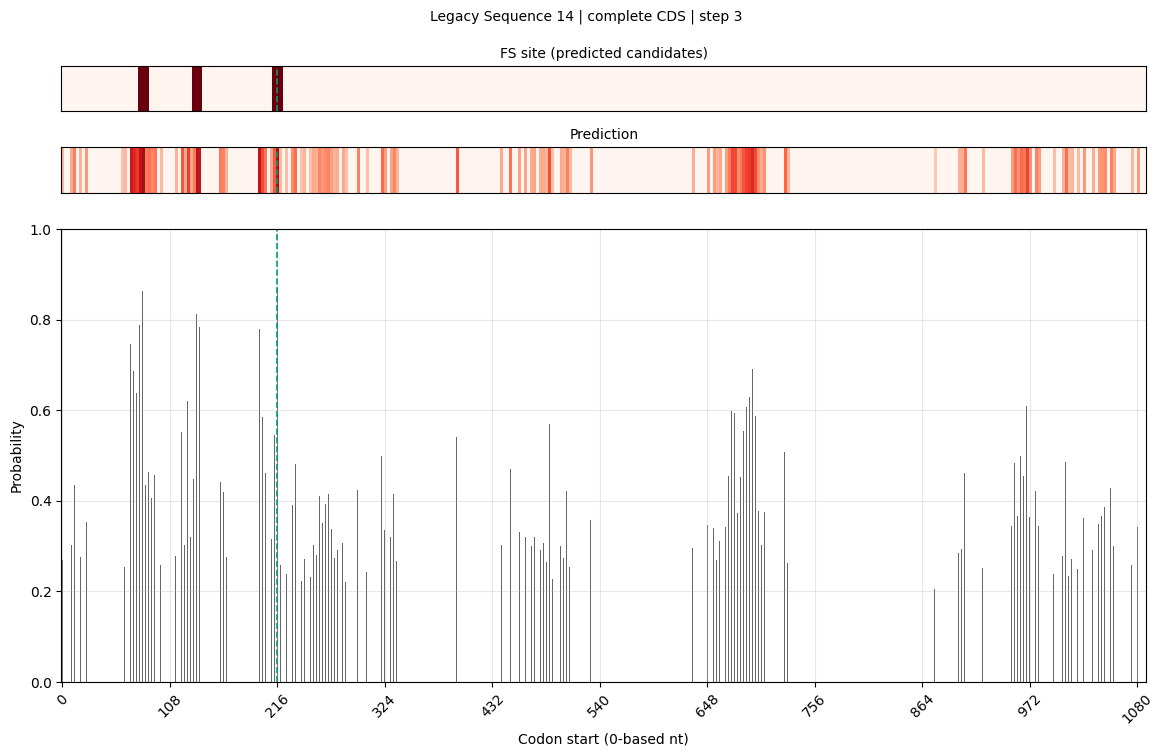

In [8]:
result, figure = legacy_plot(4, step=3)
plt.show()